In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('07-2024.csv')

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,55455014503,2024-07-01 05:51,Inbound,00:00:00,NaN,NaN
1,55461524779,2024-07-01 09:04,Outbound,00:03:07,NaN,David Valdez
2,55463776944,2024-07-01 09:07,NaN,00:04:55,NaN,David Valdez
3,55461610828,2024-07-01 09:12,Outbound,00:00:05,NaN,David Valdez
4,55463168132,2024-07-01 09:16,NaN,NaN,NaN,Robin Stoehr


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8703 entries, 0 to 8702
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             8703 non-null   int64  
 1   Activity date         8703 non-null   str    
 2   Call direction        7149 non-null   str    
 3   Call duration         7512 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  8517 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 762.4 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 8703 entries, 0 to 8702
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         8703 non-null   str  
 1   Call direction        7149 non-null   str  
 2   Call duration         7512 non-null   str  
 3   Activity assigned to  8517 non-null   str  
dtypes: str(4)
memory usage: 626.4 KB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors='coerce'
)

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 8703 entries, 0 to 8702
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         8703 non-null   datetime64[us]
 1   Call direction        7149 non-null   str           
 2   Call duration         7512 non-null   str           
 3   Activity assigned to  8517 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 490.4 KB


# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-07-01 05:51:00,Inbound,00:00:00,NaN,2024-07-01
1,2024-07-01 09:04:00,Outbound,00:03:07,David Valdez,2024-07-01
2,2024-07-01 09:07:00,NaN,00:04:55,David Valdez,2024-07-01
3,2024-07-01 09:12:00,Outbound,00:00:05,David Valdez,2024-07-01
4,2024-07-01 09:16:00,NaN,NaN,Robin Stoehr,2024-07-01


In [24]:
daily_calls =(
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [26]:
daily_calls.head()

,date,call_count
0,2024-07-01,353
1,2024-07-02,460
2,2024-07-03,376
3,2024-07-04,151
4,2024-07-05,369


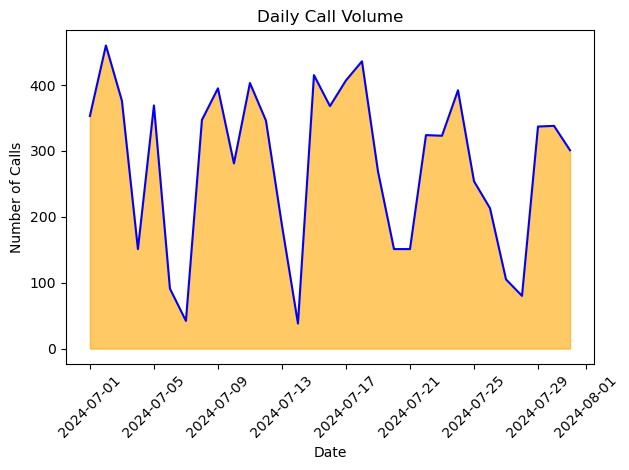

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [31]:
df1['day'] = df1['Activity date'].dt.day_name()

In [33]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-07-01 05:51:00,Inbound,00:00:00,NaN,Monday
1,2024-07-01 09:04:00,Outbound,00:03:07,David Valdez,Monday
2,2024-07-01 09:07:00,NaN,00:04:55,David Valdez,Monday
3,2024-07-01 09:12:00,Outbound,00:00:05,David Valdez,Monday
4,2024-07-01 09:16:00,NaN,NaN,Robin Stoehr,Monday


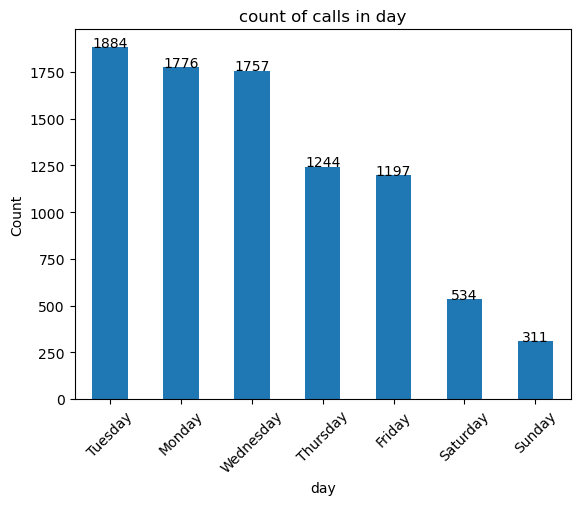

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

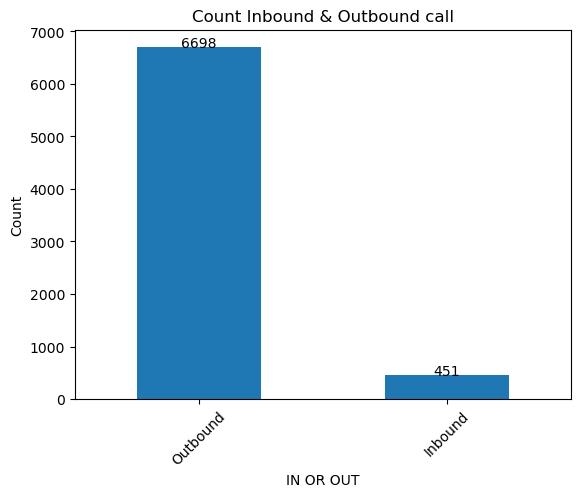

In [38]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [41]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

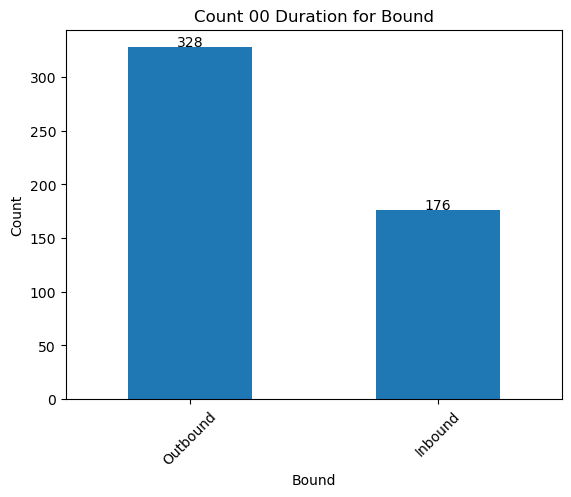

In [43]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [46]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
390,2024-07-02 11:30:00,Outbound,NaN,Sam Steindorf,Tuesday
958,2024-07-03 14:40:00,Outbound,NaN,David Valdez,Wednesday
2528,2024-07-09 18:03:00,Outbound,NaN,Juan Calo,Tuesday
2727,2024-07-10 15:13:00,Outbound,NaN,David Valdez,Wednesday
2878,2024-07-11 09:25:00,Outbound,NaN,Sam Steindorf,Thursday
3178,2024-07-11 19:01:00,Outbound,NaN,Sam Steindorf,Thursday
4259,2024-07-16 09:03:00,Outbound,NaN,David Valdez,Tuesday
4919,2024-07-17 17:18:00,Outbound,NaN,Sam Steindorf,Wednesday
5091,2024-07-18 12:00:00,Outbound,NaN,Sam Steindorf,Thursday
5968,2024-07-21 17:26:00,Outbound,NaN,Sam Steindorf,Sunday


In [48]:
df4 = df1.copy()

In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

504

In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [56]:
df4 = df4.dropna(subset = ['Call direction'])

In [58]:
(df4['Call duration'] == 0).sum()

521

In [60]:
df4.info()

<class 'pandas.DataFrame'>
Index: 7149 entries, 0 to 8702
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         7149 non-null   datetime64[us]
 1   Call direction        7149 non-null   str           
 2   Call duration         7149 non-null   float64       
 3   Activity assigned to  6974 non-null   str           
 4   day                   7149 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 525.5 KB


# Working Call Assigner

In [63]:
df1['Activity assigned to'].nunique()

18

In [65]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[                nan,      'David Valdez',      'Robin Stoehr',
         'Juan Calo',     'Garrett Evans',     'Oliver Martin',
     'Sam Steindorf',     'Keith Antonio',    'Cameron Dudley',
        'Tyler Jury', 'Brittany Digiulio',    'David Banister',
       'Paol Guzman',      'Karen Parker',   'Adonis Baybayan',
  'Chrystel Manabat',        'Henry Good',      'Bill Goodwin',
         'Terry Kim']
Length: 19, dtype: str

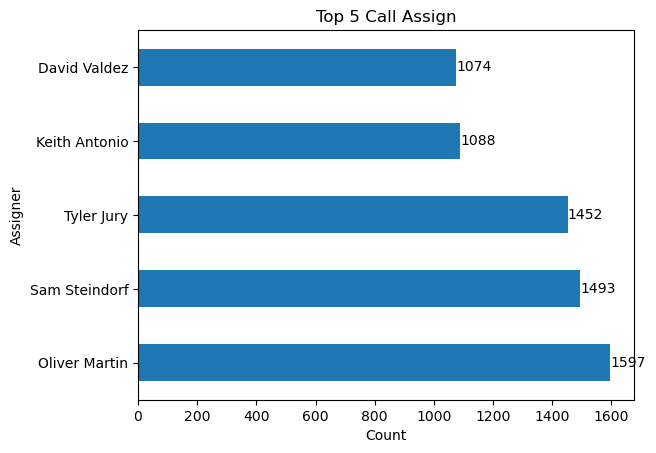

In [67]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [70]:
df4['Call duration'].max()

98.76666666666667

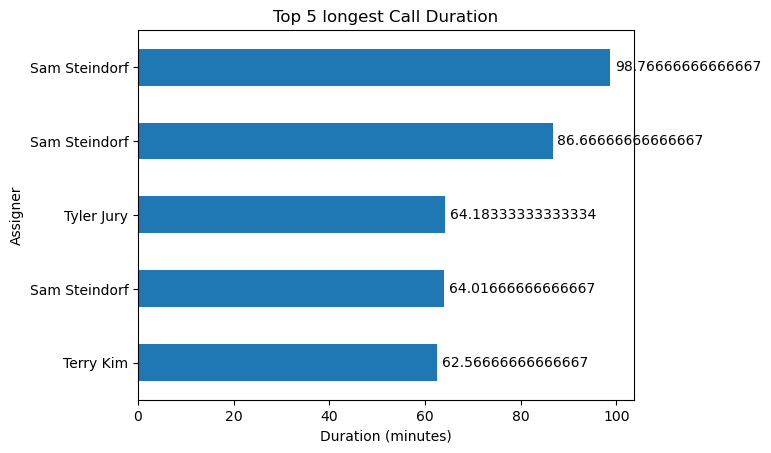

In [72]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [75]:
df3 = df1.copy()

In [77]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [79]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [81]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

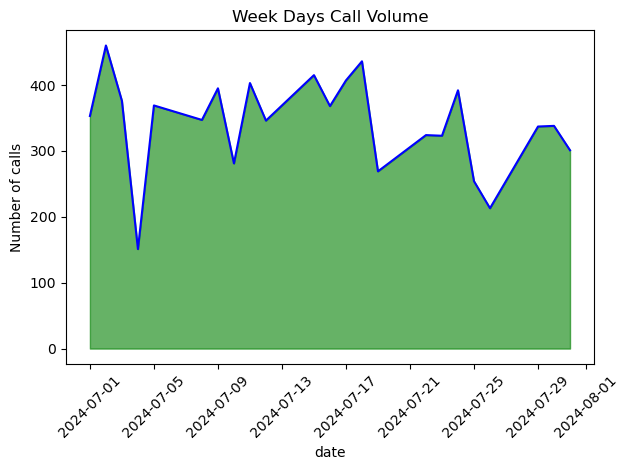

In [83]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [86]:
df5=df4.copy()

In [88]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [90]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
1709,2024-07-06 11:02:00,Outbound,0.816667,David Valdez,Saturday
1710,2024-07-06 11:03:00,Outbound,0.800000,David Valdez,Saturday
1711,2024-07-06 11:04:00,Outbound,0.850000,David Valdez,Saturday
1712,2024-07-06 11:06:00,Inbound,3.316667,David Valdez,Saturday
1714,2024-07-06 11:13:00,Outbound,0.633333,David Valdez,Saturday


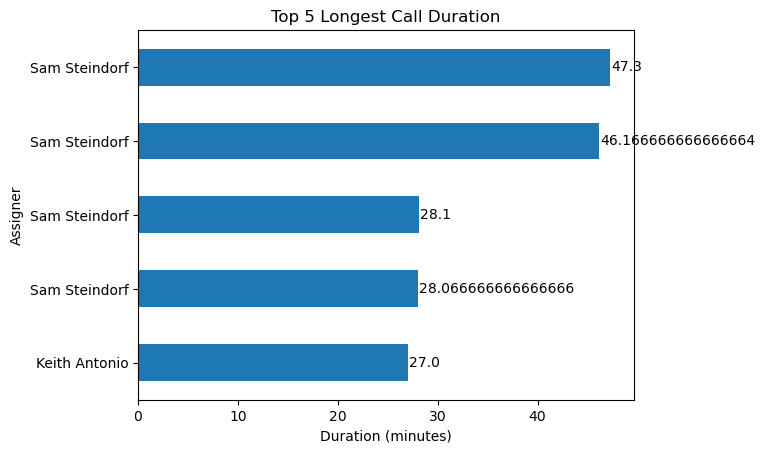

In [92]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

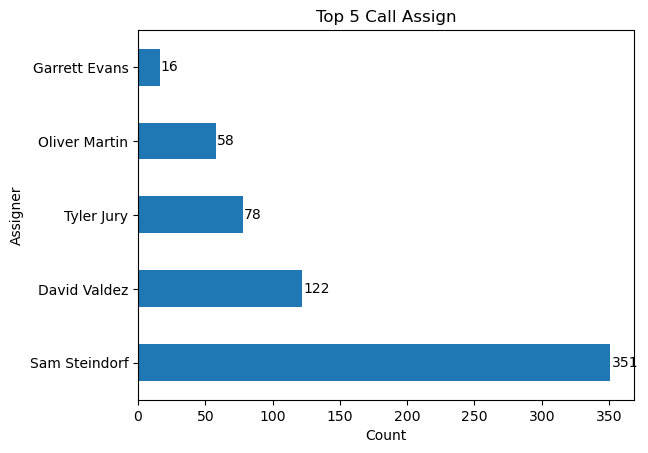

In [95]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [98]:
df4["Call duration"].mean()

2.2073786543572527

In [100]:
df4["Call duration"].median()

0.45

# Without Call Assigner Calls

In [103]:
df6 = df3.copy()

In [105]:
df6['month'] = df6['Activity date'].dt.month_name()

In [107]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

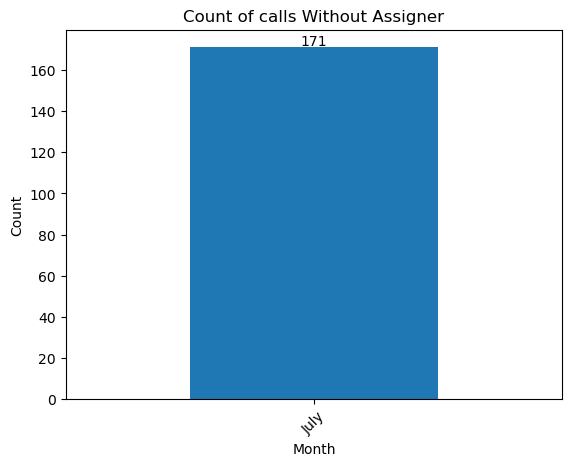

In [109]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [112]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [114]:
top5 = daily_calls.sort_values(ascending=False).head(5)

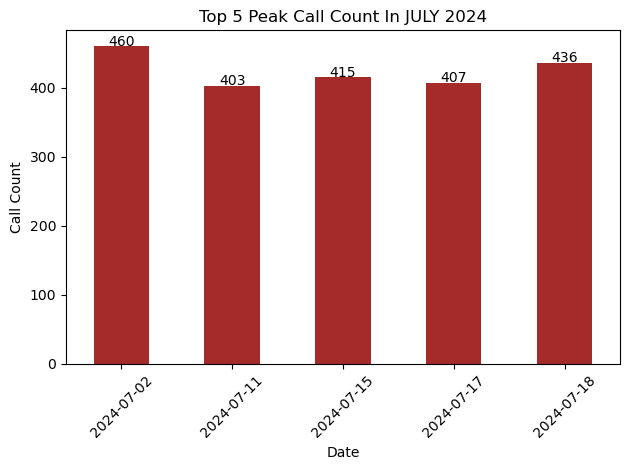

In [118]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JULY 2024")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()